Shape: (891, 8)
   Survived  Pclass     Sex        Age  SibSp  Parch    Fare Embarked
0         1       2  female  32.692102      1      1   52.27        S
1         0       3  female  27.924880      1      0   39.55        S
2         0       3    male  17.701240      0      0   24.64        S
3         0       3  female  10.224499      0      0   29.06        C
4         1       1    male   5.586126      0      0  344.98        S

Missing values:
 Survived      0
Pclass        0
Sex           0
Age         174
SibSp         0
Parch         0
Fare          0
Embarked      0
dtype: int64

After cleaning — missing values: 0


/tmp/ipykernel_1692/2310491921.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1692/2310491921.py:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

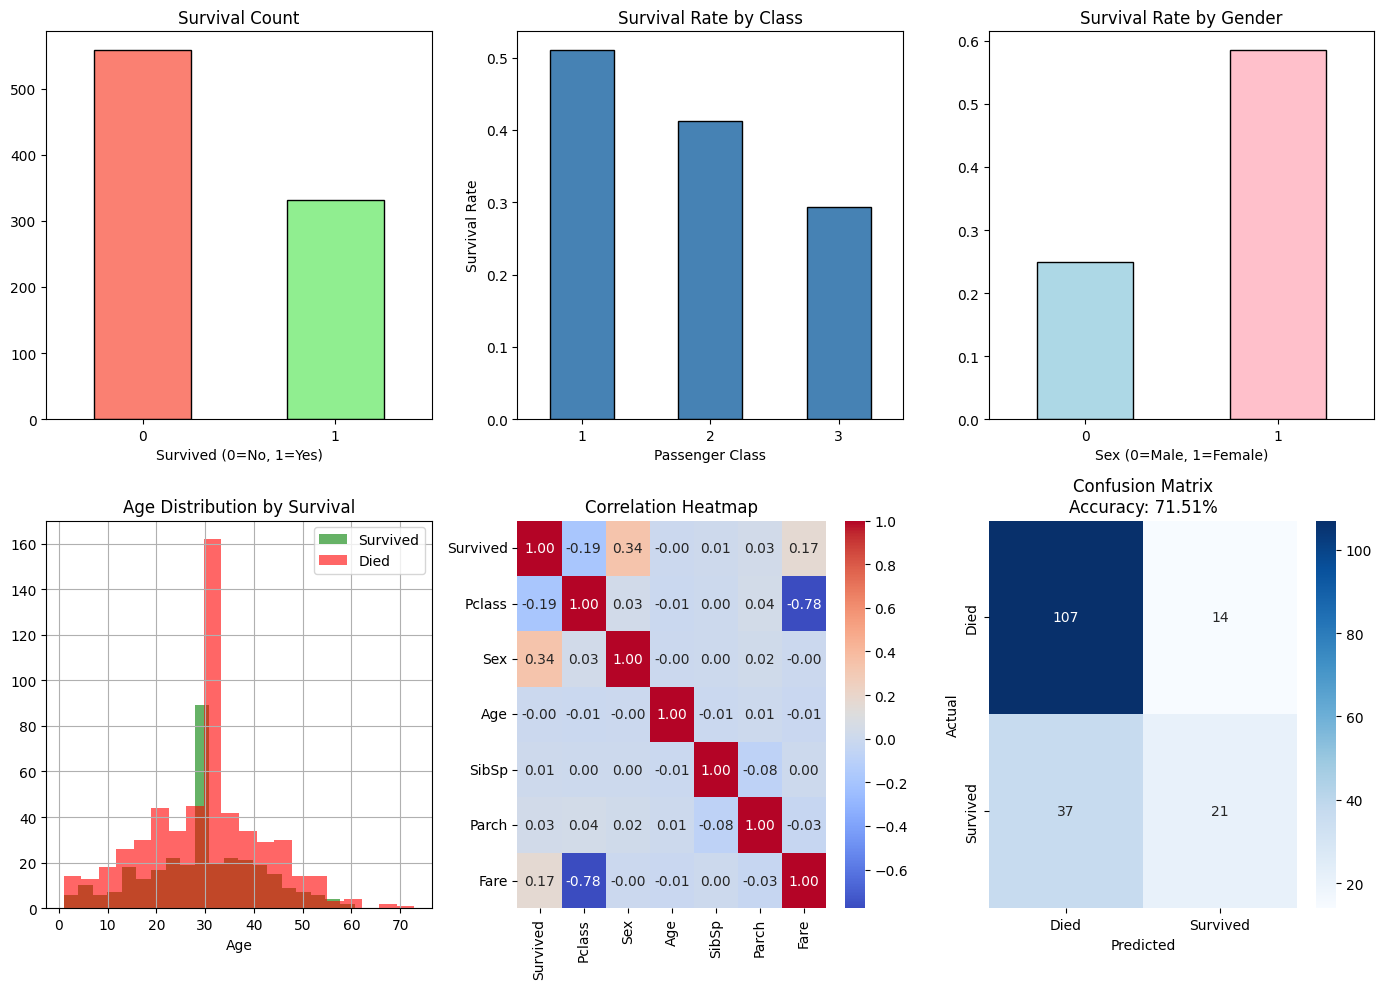


=== MODEL RESULTS ===
Model Accuracy : 71.51%

Classification Report:
              precision    recall  f1-score   support

        Died       0.74      0.88      0.81       121
    Survived       0.60      0.36      0.45        58

    accuracy                           0.72       179
   macro avg       0.67      0.62      0.63       179
weighted avg       0.70      0.72      0.69       179


Feature Importance (Logistic Regression Coefficients):
    Feature  Coefficient
1       Sex     1.488741
4     Parch     0.167536
6  Embarked     0.057476
3     SibSp     0.027439
2       Age     0.000335
5      Fare     0.000023
0    Pclass    -0.605712


In [1]:
# ============================================
# PROJECT 3: Titanic Survival Analysis + ML
# SPPU Data Science Lab - PCC-255-CAI
# Dataset: Generated in-code (no download)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
n = 891

pclass  = np.random.choice([1, 2, 3], n, p=[0.24, 0.21, 0.55])
sex_raw = np.random.choice(['male', 'female'], n, p=[0.65, 0.35])
age     = np.where(np.random.rand(n) < 0.2, np.nan,
                   np.random.normal(30, 14, n).clip(1, 80))
sibsp   = np.random.choice([0,1,2,3], n, p=[0.68,0.23,0.07,0.02])
parch   = np.random.choice([0,1,2],   n, p=[0.76,0.13,0.11])
fare    = np.where(pclass==1, np.random.uniform(50,500,n),
          np.where(pclass==2, np.random.uniform(10,80,n),
                              np.random.uniform(5,40,n))).round(2)
embarked= np.random.choice(['S','C','Q'], n, p=[0.72,0.19,0.09])

# Survival probability: women + 1st class survive more
surv_prob = (
    0.3
    + 0.35 * (sex_raw == 'female')
    - 0.15 * (pclass == 3)
    + 0.10 * (pclass == 1)
)
survived = (np.random.rand(n) < surv_prob).astype(int)

df = pd.DataFrame({
    'Survived': survived, 'Pclass': pclass,
    'Sex': sex_raw, 'Age': age,
    'SibSp': sibsp, 'Parch': parch,
    'Fare': fare, 'Embarked': embarked
})

print("Shape:", df.shape)
print(df.head())
print("\nMissing values:\n", df.isnull().sum())

# --- Data Cleaning ---
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna('S', inplace=True)
df['Sex']      = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("\nAfter cleaning — missing values:", df.isnull().sum().sum())

# --- EDA Visualizations ---
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
df['Survived'].value_counts().plot(
    kind='bar', color=['salmon','lightgreen'], edgecolor='black')
plt.title('Survival Count')
plt.xlabel('Survived (0=No, 1=Yes)'); plt.xticks(rotation=0)

plt.subplot(2, 3, 2)
df.groupby('Pclass')['Survived'].mean().plot(
    kind='bar', color='steelblue', edgecolor='black')
plt.title('Survival Rate by Class')
plt.xlabel('Passenger Class'); plt.ylabel('Survival Rate'); plt.xticks(rotation=0)

plt.subplot(2, 3, 3)
df.groupby('Sex')['Survived'].mean().plot(
    kind='bar', color=['lightblue','pink'], edgecolor='black')
plt.title('Survival Rate by Gender')
plt.xlabel('Sex (0=Male, 1=Female)'); plt.xticks(rotation=0)

plt.subplot(2, 3, 4)
df[df['Survived']==1]['Age'].hist(alpha=0.6, label='Survived', color='green', bins=20)
df[df['Survived']==0]['Age'].hist(alpha=0.6, label='Died',     color='red',   bins=20)
plt.title('Age Distribution by Survival')
plt.xlabel('Age'); plt.legend()

plt.subplot(2, 3, 5)
cols = ['Survived','Pclass','Sex','Age','SibSp','Parch','Fare']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

# --- ML Model ---
features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm  = confusion_matrix(y_test, y_pred)

plt.subplot(2, 3, 6)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died','Survived'],
            yticklabels=['Died','Survived'])
plt.title(f'Confusion Matrix\nAccuracy: {acc:.2%}')
plt.xlabel('Predicted'); plt.ylabel('Actual')

plt.tight_layout()
plt.savefig('titanic_analysis.png', dpi=100)
plt.show()

print("\n=== MODEL RESULTS ===")
print(f"Model Accuracy : {acc:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Died','Survived']))

# Feature importance
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)
print("\nFeature Importance (Logistic Regression Coefficients):")
print(coef_df)